In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder

from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

In [2]:
import pandas as pd

df = pd.read_csv("train.csv")

df.head()

,ID,Customer_ID,Month,Name,Age,SSN,Occupation,Annual_Income,Monthly_Inhand_Salary,Num_Bank_Accounts,...,Credit_Mix,Outstanding_Debt,Credit_Utilization_Ratio,Credit_History_Age,Payment_of_Min_Amount,Total_EMI_per_month,Amount_invested_monthly,Payment_Behaviour,Monthly_Balance,Credit_Score
0,0x1602,CUS_0xd40,January,Aaron Maashoh,23,821-00-0265,Scientist,19114.12,1824.843333,3,...,_,809.98,26.822620,22 Years and 1 Months,No,49.574949,80.41529543900253,High_spent_Small_value_payments,312.49408867943663,Good
1,0x1603,CUS_0xd40,February,Aaron Maashoh,23,821-00-0265,Scientist,19114.12,NaN,3,...,Good,809.98,31.944960,NaN,No,49.574949,118.28022162236736,Low_spent_Large_value_payments,284.62916249607184,Good
2,0x1604,CUS_0xd40,March,Aaron Maashoh,-500,821-00-0265,Scientist,19114.12,NaN,3,...,Good,809.98,28.609352,22 Years and 3 Months,No,49.574949,81.699521264648,Low_spent_Medium_value_payments,331.2098628537912,Good
3,0x1605,CUS_0xd40,April,Aaron Maashoh,23,821-00-0265,Scientist,19114.12,NaN,3,...,Good,809.98,31.377862,22 Years and 4 Months,No,49.574949,199.4580743910713,Low_spent_Small_value_payments,223.45130972736786,Good
4,0x1606,CUS_0xd40,May,Aaron Maashoh,23,821-00-0265,Scientist,19114.12,1824.843333,3,...,Good,809.98,24.797347,22 Years and 5 Months,No,49.574949,41.420153086217326,High_spent_Medium_value_payments,341.48923103222177,Good


In [3]:
df.head()

,ID,Customer_ID,Month,Name,Age,SSN,Occupation,Annual_Income,Monthly_Inhand_Salary,Num_Bank_Accounts,...,Credit_Mix,Outstanding_Debt,Credit_Utilization_Ratio,Credit_History_Age,Payment_of_Min_Amount,Total_EMI_per_month,Amount_invested_monthly,Payment_Behaviour,Monthly_Balance,Credit_Score
0,0x1602,CUS_0xd40,January,Aaron Maashoh,23,821-00-0265,Scientist,19114.12,1824.843333,3,...,_,809.98,26.822620,22 Years and 1 Months,No,49.574949,80.41529543900253,High_spent_Small_value_payments,312.49408867943663,Good
1,0x1603,CUS_0xd40,February,Aaron Maashoh,23,821-00-0265,Scientist,19114.12,NaN,3,...,Good,809.98,31.944960,NaN,No,49.574949,118.28022162236736,Low_spent_Large_value_payments,284.62916249607184,Good
2,0x1604,CUS_0xd40,March,Aaron Maashoh,-500,821-00-0265,Scientist,19114.12,NaN,3,...,Good,809.98,28.609352,22 Years and 3 Months,No,49.574949,81.699521264648,Low_spent_Medium_value_payments,331.2098628537912,Good
3,0x1605,CUS_0xd40,April,Aaron Maashoh,23,821-00-0265,Scientist,19114.12,NaN,3,...,Good,809.98,31.377862,22 Years and 4 Months,No,49.574949,199.4580743910713,Low_spent_Small_value_payments,223.45130972736786,Good
4,0x1606,CUS_0xd40,May,Aaron Maashoh,23,821-00-0265,Scientist,19114.12,1824.843333,3,...,Good,809.98,24.797347,22 Years and 5 Months,No,49.574949,41.420153086217326,High_spent_Medium_value_payments,341.48923103222177,Good


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 57290 entries, 0 to 57289
Data columns (total 28 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   ID                        57290 non-null  object 
 1   Customer_ID               57290 non-null  object 
 2   Month                     57290 non-null  object 
 3   Name                      51586 non-null  object 
 4   Age                       57290 non-null  object 
 5   SSN                       57290 non-null  object 
 6   Occupation                57290 non-null  object 
 7   Annual_Income             57290 non-null  object 
 8   Monthly_Inhand_Salary     48679 non-null  float64
 9   Num_Bank_Accounts         57290 non-null  int64  
 10  Num_Credit_Card           57290 non-null  int64  
 11  Interest_Rate             57290 non-null  int64  
 12  Num_of_Loan               57290 non-null  object 
 13  Type_of_Loan              50794 non-null  object 
 14  Delay_

In [5]:
df.describe()

,Monthly_Inhand_Salary,Num_Bank_Accounts,Num_Credit_Card,Interest_Rate,Delay_from_due_date,Num_Credit_Inquiries,Credit_Utilization_Ratio,Total_EMI_per_month
count,48679.000000,57290.000000,57290.000000,57290.000000,57290.000000,56201.000000,57290.000000,57290.000000
mean,4198.153810,16.920702,22.740862,70.900384,21.164008,27.477661,32.314379,1414.703479
std,3200.637947,116.824612,130.511869,459.838861,14.866309,189.782743,5.113238,8389.416198
min,319.556250,-1.000000,0.000000,1.000000,-5.000000,0.000000,20.000000,0.000000
25%,1623.664167,3.000000,4.000000,8.000000,10.000000,3.000000,28.087180,30.759834
50%,3081.243333,6.000000,6.000000,13.000000,18.000000,6.000000,32.350393,68.988886
75%,5957.448333,7.000000,7.000000,20.000000,28.000000,9.000000,36.527735,162.488448
max,15136.696667,1798.000000,1499.000000,5788.000000,67.000000,2597.000000,50.000000,82256.000000


In [6]:
df.isnull().sum()

,0
ID,0
Customer_ID,0
Month,0
Name,5704
Age,0
SSN,0
Occupation,0
Annual_Income,0
Monthly_Inhand_Salary,8611
Num_Bank_Accounts,0


In [7]:
df = df.dropna()

In [8]:
df.isnull().sum()

,0
ID,0
Customer_ID,0
Month,0
Name,0
Age,0
SSN,0
Occupation,0
Annual_Income,0
Monthly_Inhand_Salary,0
Num_Bank_Accounts,0


In [9]:
encoder = LabelEncoder()

for col in df.columns:
    if df[col].dtype == 'object':
        df[col] = encoder.fit_transform(df[col])

In [10]:
df.head()

,ID,Customer_ID,Month,Name,Age,SSN,Occupation,Annual_Income,Monthly_Inhand_Salary,Num_Bank_Accounts,...,Credit_Mix,Outstanding_Debt,Credit_Utilization_Ratio,Credit_History_Age,Payment_of_Min_Amount,Total_EMI_per_month,Amount_invested_monthly,Payment_Behaviour,Monthly_Balance,Credit_Score
0,8835,6253,3,48,120,5187,12,2645,1824.843333,3,...,3,6054,26.822620,180,1,49.574949,26046,3,13893,0
6,8877,6253,4,48,120,5187,12,2645,1824.843333,3,...,1,6054,22.537593,188,1,49.574949,8193,6,5239,0
8,8911,525,3,4162,172,29,15,4547,3037.986667,2,...,1,5454,24.464031,236,1,18.816215,613,6,23937,2
9,8919,525,2,4162,165,29,13,4547,3037.986667,2,...,1,5454,38.550848,237,1,18.816215,17421,1,24331,0
10,8926,525,6,4162,165,29,13,4548,3037.986667,2,...,3,5454,33.224951,238,1,18.816215,21811,1,23809,2


In [11]:
X = df.drop("Credit_Score", axis=1)

In [12]:
y = df["Credit_Score"]

In [13]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [14]:
model = RandomForestClassifier(random_state=42)

model.fit(X_train, y_train)

RandomForestClassifier(random_state=42)

In [15]:
y_pred = model.predict(X_test)

In [16]:
accuracy = accuracy_score(y_test, y_pred)

print("Accuracy:", accuracy)

Accuracy: 0.7858197932053176


In [17]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.73      0.71      0.72       976
           1       0.79      0.79      0.79      1896
           2       0.80      0.81      0.80      3221

    accuracy                           0.79      6093
   macro avg       0.77      0.77      0.77      6093
weighted avg       0.79      0.79      0.79      6093



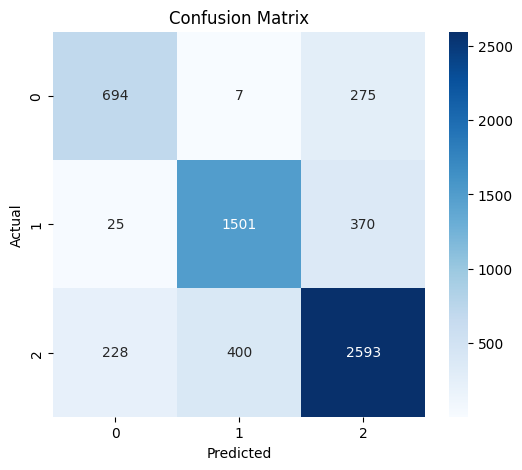

In [18]:
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6,5))
sns.heatmap(cm,
            annot=True,
            fmt='d',
            cmap='Blues')

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")

plt.show()

In [19]:
importance = model.feature_importances_

feature_importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": importance
})

feature_importance = feature_importance.sort_values(
    by="Importance",
    ascending=False
)

print(feature_importance)

                     Feature  Importance
11             Interest_Rate    0.086784
19          Outstanding_Debt    0.061010
14       Delay_from_due_date    0.059686
18                Credit_Mix    0.053645
17      Num_Credit_Inquiries    0.047873
21        Credit_History_Age    0.042128
0                         ID    0.041507
16      Changed_Credit_Limit    0.040004
10           Num_Credit_Card    0.036470
26           Monthly_Balance    0.035833
20  Credit_Utilization_Ratio    0.034239
8      Monthly_Inhand_Salary    0.034218
9          Num_Bank_Accounts    0.033922
7              Annual_Income    0.033634
24   Amount_invested_monthly    0.032700
23       Total_EMI_per_month    0.032646
3                       Name    0.032366
1                Customer_ID    0.032199
13              Type_of_Loan    0.031355
5                        SSN    0.030473
4                        Age    0.029940
15    Num_of_Delayed_Payment    0.027003
12               Num_of_Loan    0.026131
22     Payment_o

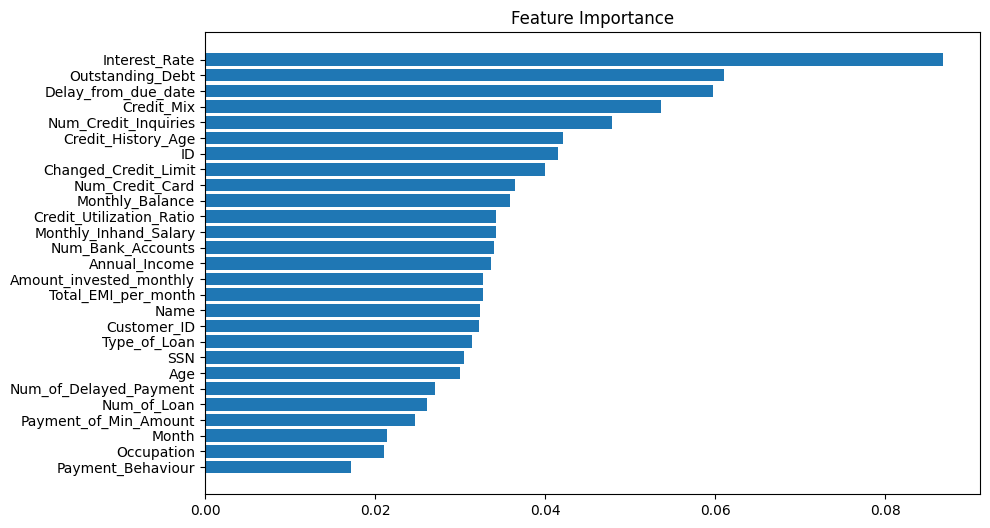

In [20]:
plt.figure(figsize=(10,6))

plt.barh(
    feature_importance["Feature"],
    feature_importance["Importance"]
)

plt.gca().invert_yaxis()

plt.title("Feature Importance")

plt.show()

In [21]:
sample = X.iloc[[0]]

prediction = model.predict(sample)

print("Predicted Credit Score:", prediction)

Predicted Credit Score: [0]
